## 1. Setup and Path Configuration

In [ ]:
import json
import cv2
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
from pycocotools import mask as mask_utils

# ================= CONFIGURAÇÃO DE CAMINHOS =================
unb_server = True

BASE_DIR = "/home/antoniovinicius/projects/sandbox_sam3" if unb_server else "/home/avmoura_linux/Documents/unb/sandbox_sam3"
DATASET_DIR = f"{BASE_DIR}/datasets/ph2/"
LOG_DIR = Path(f"{BASE_DIR}/logs/olds/ph2_train_seg_500_3")

CONFIG = {
    "train_stats": LOG_DIR / "train_stats.json",
    "val_stats": LOG_DIR / "val_stats.json",
    "best_stats": LOG_DIR / "best_stats.json",
    
    # Configurações do seu script de visualização
    "images_dir": Path(f"{DATASET_DIR}/test/"), #aqui deveria ser "valid"
    "gt_json": Path(f"{DATASET_DIR}/test/_annotations.coco.json"), #aqui deveria ser "valid"
    "pred_json": Path(f"{LOG_DIR}/dumps/ph2/coco_predictions_segm.json"),
    "score_threshold": 0.35,
    "mask_alpha": 0.45
}

## 2. Data Loading

In [ ]:
def load_jsonl(filepath: Path) -> pd.DataFrame:
    if not filepath.exists():
        print(f"File not found: {filepath}")
        return pd.DataFrame()
        
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line.strip()))
    return pd.DataFrame(data)

# Carregando as métricas
df_train = load_jsonl(CONFIG["train_stats"])
df_val = load_jsonl(CONFIG["val_stats"])
df_best = load_jsonl(CONFIG["best_stats"])

print(f"Training lines loaded: {len(df_train)}")
print(f"Validation lines loaded: {len(df_val)}")

## 3. Training Loss Analysis

In [ ]:
# Definindo as métricas principais de treino que queremos observar
train_metrics = {
    "Total Loss": ("Losses/train_all_loss", "black"),
    "BBox Loss": ("Losses/train_all_loss_bbox", "red"),
    "GIoU Loss": ("Losses/train_all_loss_giou", "green"),
    "Cross-Entropy Loss": ("Losses/train_all_loss_ce", "blue")
}

fig, axes = plt.subplots(len(train_metrics), 1, figsize=(12, 4 * len(train_metrics)))

for i, (title, (col_name, color)) in enumerate(train_metrics.items()):
    if col_name in df_train.columns:
        axes[i].plot(df_train.index, df_train[col_name], color=color, alpha=0.8)
        axes[i].set_title(f"Training {title}", fontsize=14)
        axes[i].set_xlabel("Epochs")
        axes[i].set_ylabel("Loss")
        axes[i].grid(True, linestyle="--", alpha=0.6)
    else:
        axes[i].text(0.5, 0.5, f"Metric {col_name} not found", ha="center", va="center")

plt.tight_layout()
plt.show()

## 4. Validation Metrics

In [ ]:
# Loss de treino vs AP de validação
epochs_train = df_train['Trainer/epoch'] if 'Trainer/epoch' in df_train.columns else df_train.index
epochs_val = df_val['Trainer/epoch'] if 'Trainer/epoch' in df_val.columns else df_val.index

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y esquerdo: Loss de treino
color1 = 'black'
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Training Total Loss', color=color1, fontsize=12)
if "Losses/train_all_loss" in df_train.columns:
    ax1.plot(epochs_train, df_train["Losses/train_all_loss"], color=color1, label="Train Loss", alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle="--", alpha=0.6)

# Cria segundo eixo Y (direito) para AP
ax2 = ax1.twinx()
color2 = 'teal'
ax2.set_ylabel('Validation AP (Mask)', color=color2, fontsize=12)

# Usa AP de segmentação como métrica principal
val_metric = 'Meters_train/val_ph2_eval/detection/coco_eval_segm_AP'
if val_metric in df_val.columns:
    ax2.plot(epochs_val, df_val[val_metric], color=color2, marker='o', label="Val Mask AP", linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Junta as legendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=12)

plt.title("Learning Curve: Training Loss vs Validation AP", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
epoch_col = 'Trainer/epoch'
mask_ap50 = 'Meters_train/val_ph2_eval/detection/coco_eval_segm_AP_50'
mask_ap95 = 'Meters_train/val_ph2_eval/detection/coco_eval_segm_AP'
box_ap50  = 'Meters_train/val_ph2_eval/detection/coco_eval_bbox_AP_50'
box_ap95  = 'Meters_train/val_ph2_eval/detection/coco_eval_bbox_AP'

# Gráfico de métricas AP (estilo YOLO)
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('AP Score', fontsize=12)

# Máscaras
if mask_ap50 in df_val.columns and mask_ap95 in df_val.columns:
    ax1.plot(df_val[epoch_col], df_val[mask_ap50], color='teal', label='Mask AP@50', linewidth=2)
    ax1.plot(df_val[epoch_col], df_val[mask_ap95], color='darkcyan', linestyle='--', label='Mask AP@50-95', linewidth=2)

# Caixas delimitadoras (BBox)
if box_ap50 in df_val.columns and box_ap95 in df_val.columns:
    ax1.plot(df_val[epoch_col], df_val[box_ap50], color='orange', label='Box AP@50', linewidth=2)
    ax1.plot(df_val[epoch_col], df_val[box_ap95], color='darkorange', linestyle='--', label='Box AP@50-95', linewidth=2)

ax1.set_title("SAM3 Validation Metrics: Mask and Box AP vs Epochs", fontsize=14)
ax1.legend(loc='lower right', fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Qualitative Results (Inference on Test Set)

In [ ]:
OVERLAY_MASKS = True  # Mude para False para ver lado a lado

def load_json_data(pred_path: Path, gt_path: Path) -> Tuple[Dict[int, List[Dict]], Dict[int, List[Dict]], Dict[int, str]]:
    preds_map, gt_map, id_to_filename = {}, {}, {}
    
    if pred_path.exists():
        with open(pred_path, 'r') as f:
            preds = json.load(f)
        for p in preds:
            preds_map.setdefault(p['image_id'], []).append(p)

    if gt_path.exists():
        with open(gt_path, 'r') as f:
            gt = json.load(f)
        for img in gt['images']:
            id_to_filename[img['id']] = img['file_name']
        for ann in gt.get('annotations', []):
            gt_map.setdefault(ann['image_id'], []).append(ann)
            
    return preds_map, gt_map, id_to_filename

def apply_mask(image: np.ndarray, mask: np.ndarray, color: List[int], alpha: float):
    for c in range(3):
        image[:, :, c] = np.where(mask == 1,
                                  image[:, :, c] * (1 - alpha) + alpha * color[c],
                                  image[:, :, c])
    return image

def draw_visualizations(img: np.ndarray, annotations: List[Dict], threshold: float = 0.0, is_gt: bool = False, color_override: List[int] = None) -> Tuple[int, np.ndarray]:
    count = 0
    img_h, img_w = img.shape[:2]
    
    # Ordena predições pelo score
    if not is_gt:
        annotations.sort(key=lambda x: x.get('score', 0)) 

    for ann in annotations:
        score = ann.get('score', 1.0)
        if not is_gt and score < threshold: 
            continue

        # Define cores: Verde para GT, Aleatório/Fixo para predição
        if color_override:
            color = color_override
        else:
            color = [0, 255, 0] if is_gt else [random.randint(50, 255) for _ in range(3)]
        
        # Aplica máscara
        if 'segmentation' in ann:
            try:
                segm = ann['segmentation']
                binary_mask = np.zeros((img_h, img_w), dtype=np.uint8)
                
                # Formato polígono (COCO)
                if isinstance(segm, list):
                    for poly in segm:
                        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
                        cv2.fillPoly(binary_mask, [pts], 1)
                
                # Formato RLE (Predição)
                elif isinstance(segm, dict):
                    binary_mask = mask_utils.decode(segm)
                    if binary_mask.shape[:2] != (img_h, img_w):
                        binary_mask = cv2.resize(binary_mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

                img = apply_mask(img, binary_mask, color, CONFIG["mask_alpha"])
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(img, contours, -1, (255, 255, 255), 1)
            except Exception as e:
                pass

        # Desenha bounding box
        if 'bbox' in ann:
            bbox = ann['bbox']
            if all(v <= 1.1 for v in bbox):
                x, y, w, h = int(bbox[0]*img_w), int(bbox[1]*img_h), int(bbox[2]*img_w), int(bbox[3]*img_h)
            else:
                x, y, w, h = map(int, bbox)
                
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            
            # Adiciona texto
            if not is_gt:
                label = f"Pred: {score:.2f}"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(img, (x, y - 20), (x + tw, y), color, -1)
                cv2.putText(img, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            else:
                label = "GT"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                # Ajusta posição do texto do GT para não sobrepor
                offset_x = x + 80 if OVERLAY_MASKS else x
                cv2.rectangle(img, (offset_x, y - 20), (offset_x + tw, y), color, -1)
                cv2.putText(img, label, (offset_x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
                
        count += 1
        
    return count, img

NUM_IMAGES_TO_SHOW = 10
preds_map, gt_map, id_to_filename = load_json_data(CONFIG["pred_json"], CONFIG["gt_json"])
shown = 0

for img_id, predictions in preds_map.items():
    if shown >= NUM_IMAGES_TO_SHOW:
        break
        
    if id_to_filename and img_id in id_to_filename:
        img_path = CONFIG["images_dir"] / id_to_filename[img_id]
        if not img_path.exists():
            continue
            
        original_img = cv2.imread(str(img_path))
        if original_img is None:
            continue
            
        gt_annotations = gt_map.get(img_id, [])
        
        if OVERLAY_MASKS:
            # Mostra na mesma imagem
            combined_img = original_img.copy()
            
            # 1. Ground Truth (Verde)
            gt_count, combined_img = draw_visualizations(combined_img, gt_annotations, is_gt=True, color_override=[113, 204, 46])
            
            # 2. Previsões (Vermelho)
            # OpenCV usa BGR
            pred_count, combined_img = draw_visualizations(combined_img, predictions, CONFIG["score_threshold"], is_gt=False, color_override=[60, 20, 220])
            
            if pred_count > 0 or gt_count > 0:
                combined_img_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
                
                plt.figure(figsize=(10, 10))
                plt.imshow(combined_img_rgb)
                plt.title(f"Image: {id_to_filename[img_id]}\nGT (Green) | Prediction (Red)", fontsize=14)
                plt.axis('off')
                plt.tight_layout()
                plt.show()
                shown += 1
                
        else:
            # Mostra imagens lado a lado
            pred_count, img_pred = draw_visualizations(original_img.copy(), predictions, CONFIG["score_threshold"], is_gt=False)
            gt_count, img_gt = draw_visualizations(original_img.copy(), gt_annotations, is_gt=True)
            
            if pred_count > 0 or gt_count > 0:
                img_pred_rgb = cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB)
                img_gt_rgb = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)
                
                fig, axes = plt.subplots(1, 2, figsize=(16, 8))
                
                axes[0].imshow(img_pred_rgb)
                axes[0].set_title(f"Model Predictions (Threshold: {CONFIG['score_threshold']})", fontsize=14)
                axes[0].axis('off')
                
                axes[1].imshow(img_gt_rgb)
                axes[1].set_title(f"Ground Truth", fontsize=14)
                axes[1].axis('off')
                
                fig.suptitle(f"Image: {id_to_filename[img_id]}", fontsize=16)
                plt.tight_layout()
                plt.show()
                shown += 1

## 6. Metrics Presentation

In [ ]:
print("="*50)
print("🎯 VALIDATION RESULTS (LAST EPOCH) 🎯")
print("="*50)

if not df_val.empty:
    last_epoch_data = df_val.iloc[-1]
    epoch_num = last_epoch_data.get('Trainer/epoch', 'N/A')
    
    print(f"Analyzed Epoch: {epoch_num}\n")
    
    metrics_to_print = {}
    for col, value in last_epoch_data.items():
        if "coco_eval" in col and pd.notna(value) and value != -1.0:
            clean_name = col.split('/')[-1].replace('coco_eval_', '')
            metrics_to_print[clean_name] = value

    for name, value in sorted(metrics_to_print.items()):
        if 'segm' in name:
            print(f"  🟦 Mask {name.replace('segm_', '')}: \t{value:.4f}")
        elif 'bbox' in name:
            print(f"  🟩 BBox {name.replace('bbox_', '')}: \t{value:.4f}")
else:
    print("No validation metrics found.")
print("="*50)

## 7. Model Inference (Test Set)

In [ ]:
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# ================= CONFIGURAÇÃO DE INFERÊNCIA =================
INFERENCE_CONFIG = {
    "test_images_dir": Path(f"{DATASET_DIR}/test/"),
    "test_gt_json": Path(f"{DATASET_DIR}/test/_annotations.coco.json"), # Caminho do GT de teste
    "model_weights": LOG_DIR / "checkpoints/checkpoint.pt",
    "prompt": "kin-Lesions-Wb1v", 
    "conf_threshold": 0.20,
    "mask_alpha": 0.45,
    "num_images_to_show": 10 # Atualizado para 10 como no seu código
}

def draw_sam3_predictions(img_cv: np.ndarray, results: dict, prompt_label: str, alpha: float = 0.45, color_override: list = None) -> np.ndarray:
    """Desenha máscaras e bboxes do SAM3."""
    result_img = img_cv.copy()
    total_objects = len(results.get("scores", []))
    h, w = result_img.shape[:2]
    line_width = 2

    for i in range(total_objects):
        # Usa a cor fixa se fornecida, senão gera aleatória/paleta
        color = color_override if color_override else [random.randint(50, 255) for _ in range(3)]
        prob = results["scores"][i].item()

        # 1. Desenhar Máscara
        if "masks" in results and len(results["masks"]) > i:
            mask = results["masks"][i].squeeze(0).cpu().numpy()
            
            if mask.shape != (h, w):
                if mask.shape == (w, h): mask = mask.T
                else: mask = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
            
            mask_bool = mask.astype(bool)
            overlay = result_img.copy()
            overlay[mask_bool] = color
            result_img = cv2.addWeighted(result_img, 1 - alpha, overlay, alpha, 0)

            contours, _ = cv2.findContours(mask_bool.astype(np.uint8) * 255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(result_img, contours, -1, color, max(1, line_width // 2))

        # 2. Desenhar BBox e Texto
        if "boxes" in results and len(results["boxes"]) > i:
            box = results["boxes"][i].cpu().numpy()
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(result_img, (x1, y1), (x2, y2), color, line_width)
            
            label = f"Pred: {prob:.2f}"
            font_scale, text_thickness = 0.5, 1
            (text_w, text_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness)
            
            label_y = max(y1, text_h + 3)
            cv2.rectangle(result_img, (x1, label_y - text_h - 3), (x1 + text_w + 6, label_y + baseline), color, -1)
            cv2.putText(result_img, label, (x1 + 3, label_y - 3), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), text_thickness, cv2.LINE_AA)

    return result_img

# ================= CARREGAMENTO DO MODELO =================
print(f"Loading SAM3 model from: {INFERENCE_CONFIG['model_weights']}")
model = build_sam3_image_model(checkpoint_path=str(INFERENCE_CONFIG["model_weights"]))
processor = Sam3Processor(model, confidence_threshold=INFERENCE_CONFIG["conf_threshold"])
print("Model successfully loaded and ready for inference!")

Loading SAM3 model from: /home/antoniovinicius/projects/sandbox_sam3/logs/olds/ph2_train_seg_500_3/checkpoints/checkpoint.pt
loaded /home/antoniovinicius/projects/sandbox_sam3/logs/olds/ph2_train_seg_500_3/checkpoints/checkpoint.pt and found missing and/or unexpected keys:
missing_keys=['backbone.vision_backbone.trunk.pos_embed', 'backbone.vision_backbone.trunk.patch_embed.proj.weight', 'backbone.vision_backbone.trunk.blocks.0.norm1.weight', 'backbone.vision_backbone.trunk.blocks.0.norm1.bias', 'backbone.vision_backbone.trunk.blocks.0.attn.freqs_cis', 'backbone.vision_backbone.trunk.blocks.0.attn.qkv.weight', 'backbone.vision_backbone.trunk.blocks.0.attn.qkv.bias', 'backbone.vision_backbone.trunk.blocks.0.attn.proj.weight', 'backbone.vision_backbone.trunk.blocks.0.attn.proj.bias', 'backbone.vision_backbone.trunk.blocks.0.norm2.weight', 'backbone.vision_backbone.trunk.blocks.0.norm2.bias', 'backbone.vision_backbone.trunk.blocks.0.mlp.fc1.weight', 'backbone.vision_backbone.trunk.blocks.0

Running inference and comparing with GT for 10 images...



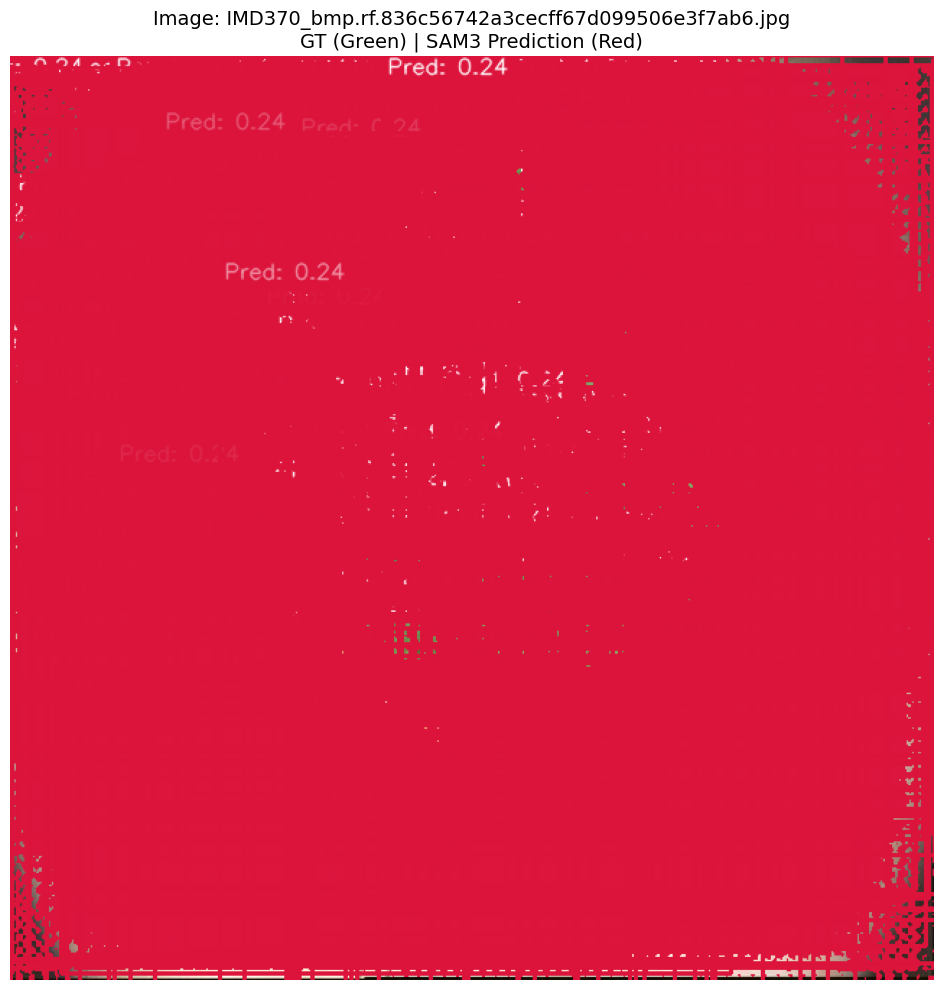

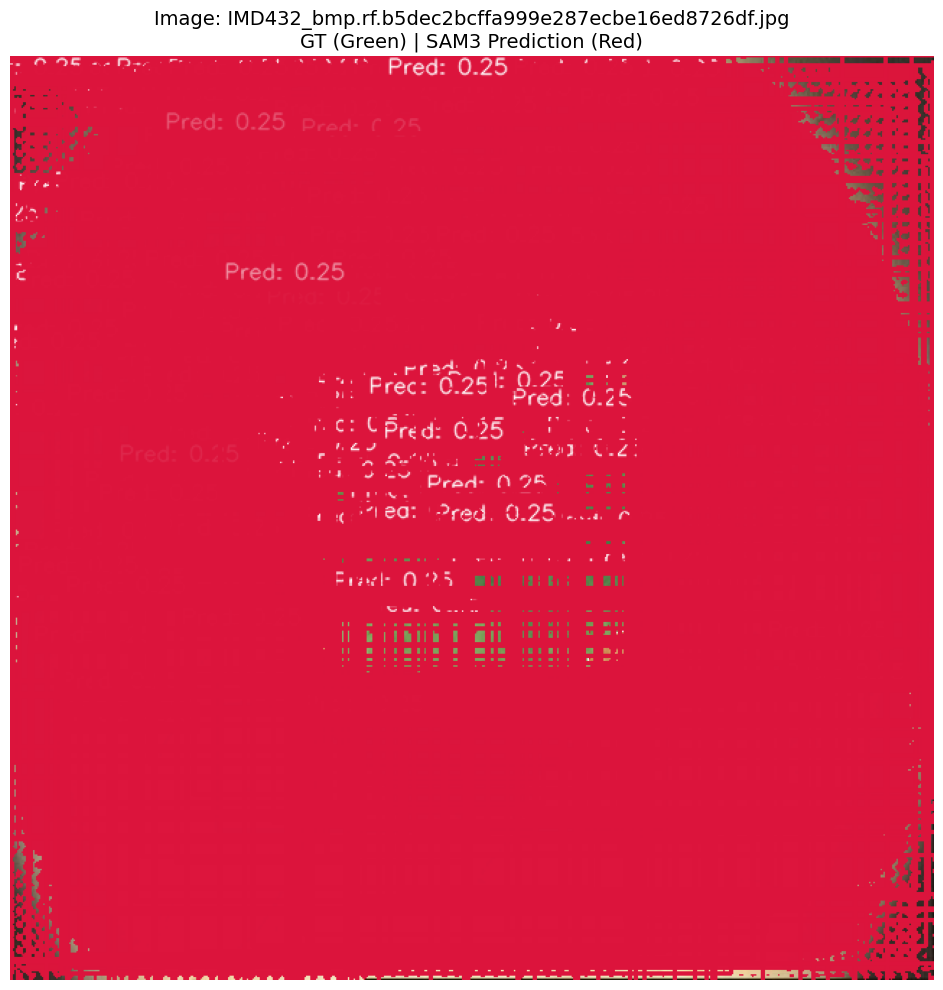

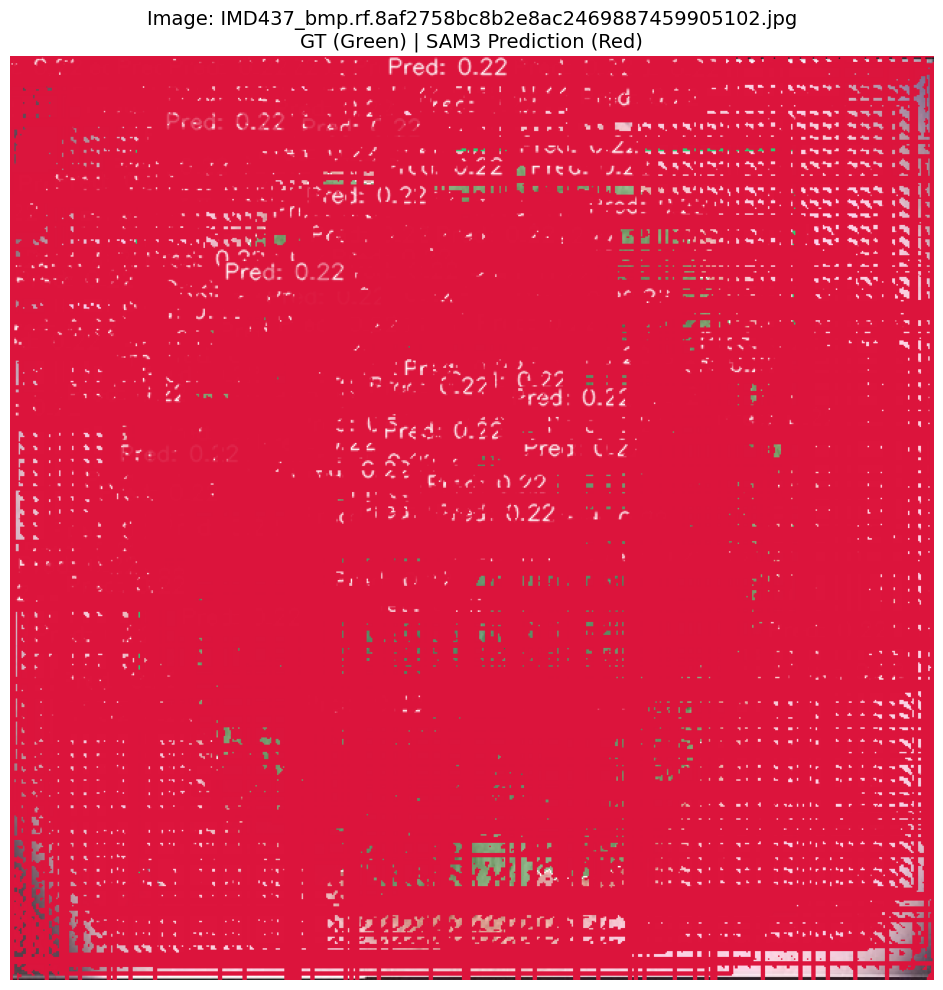

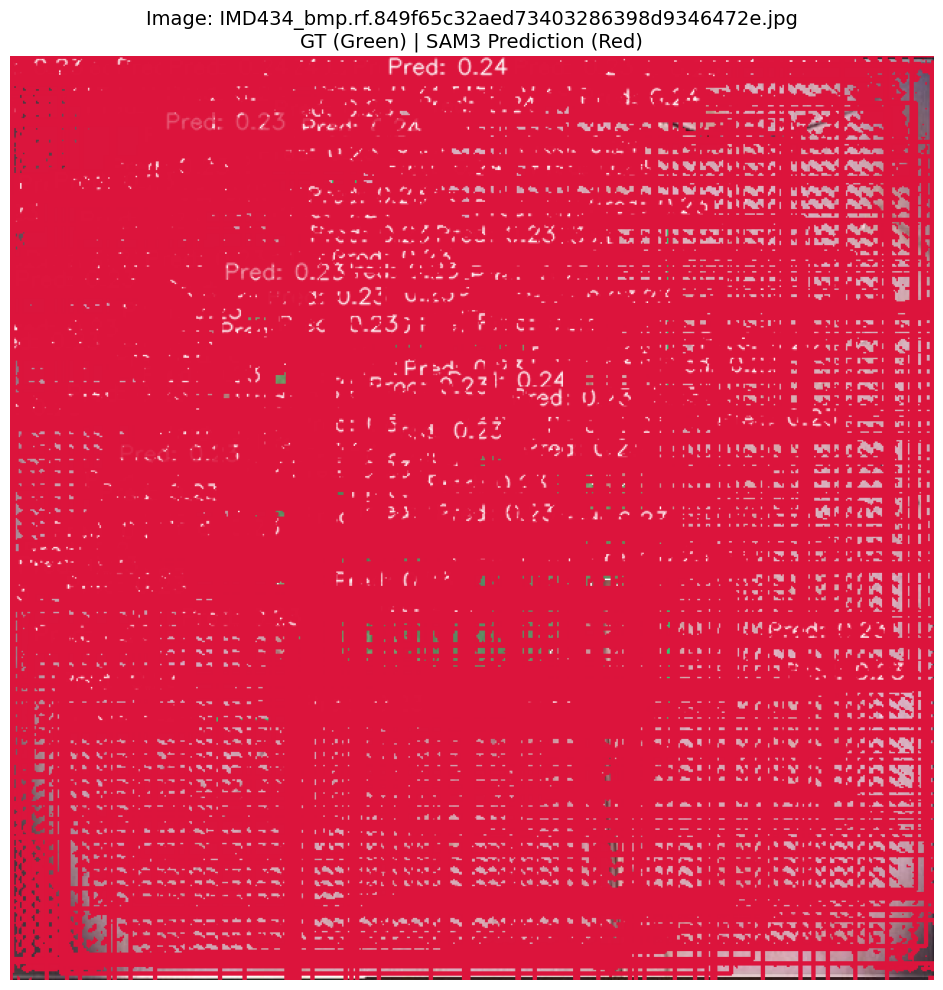

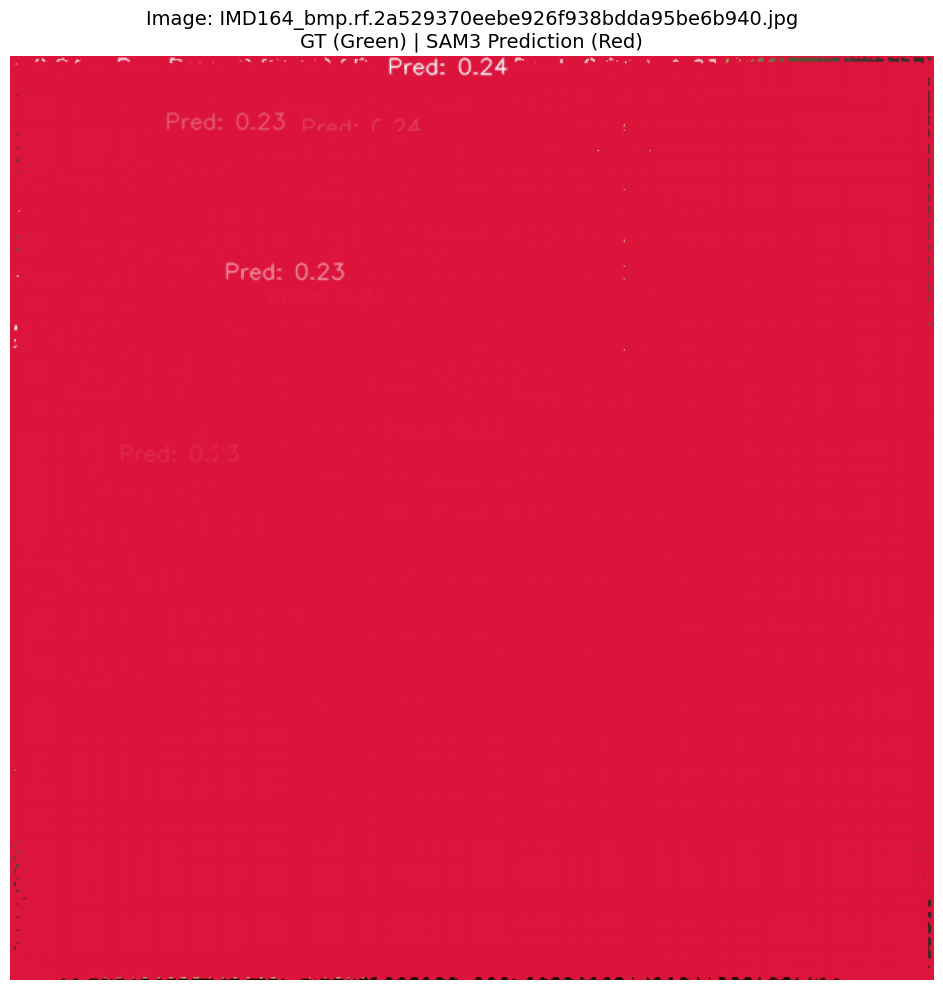

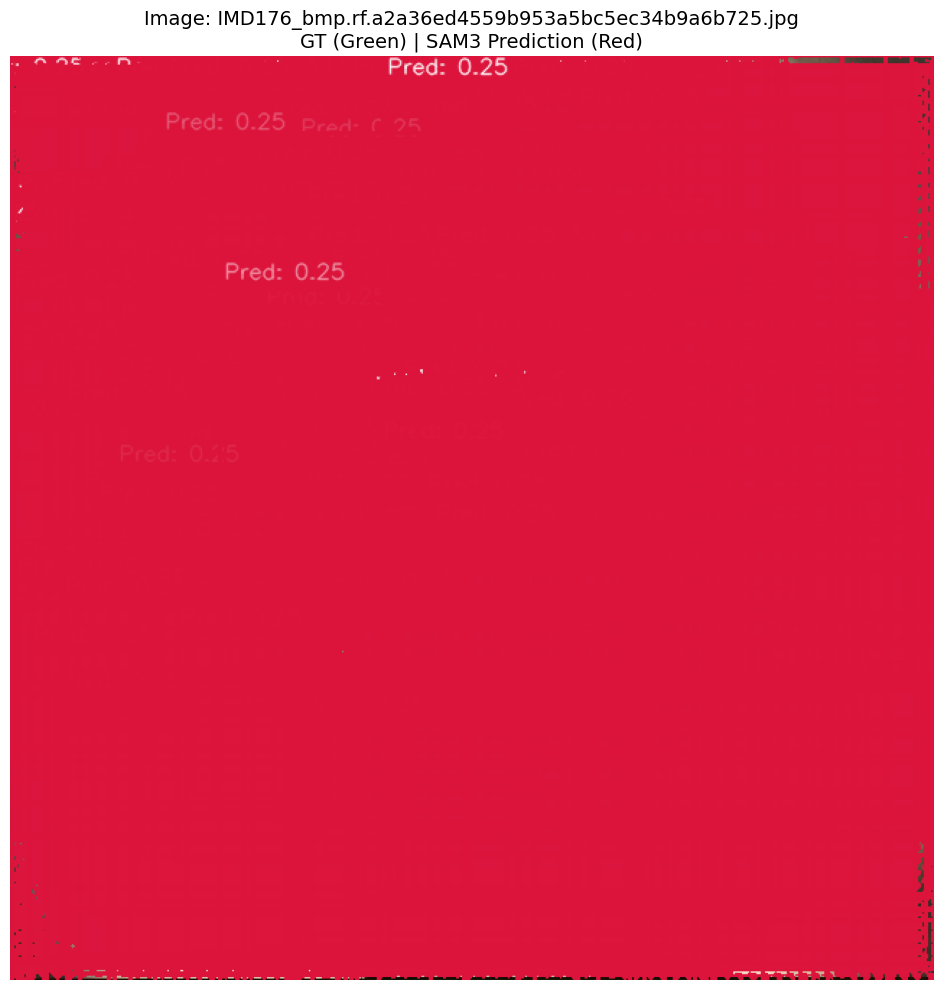

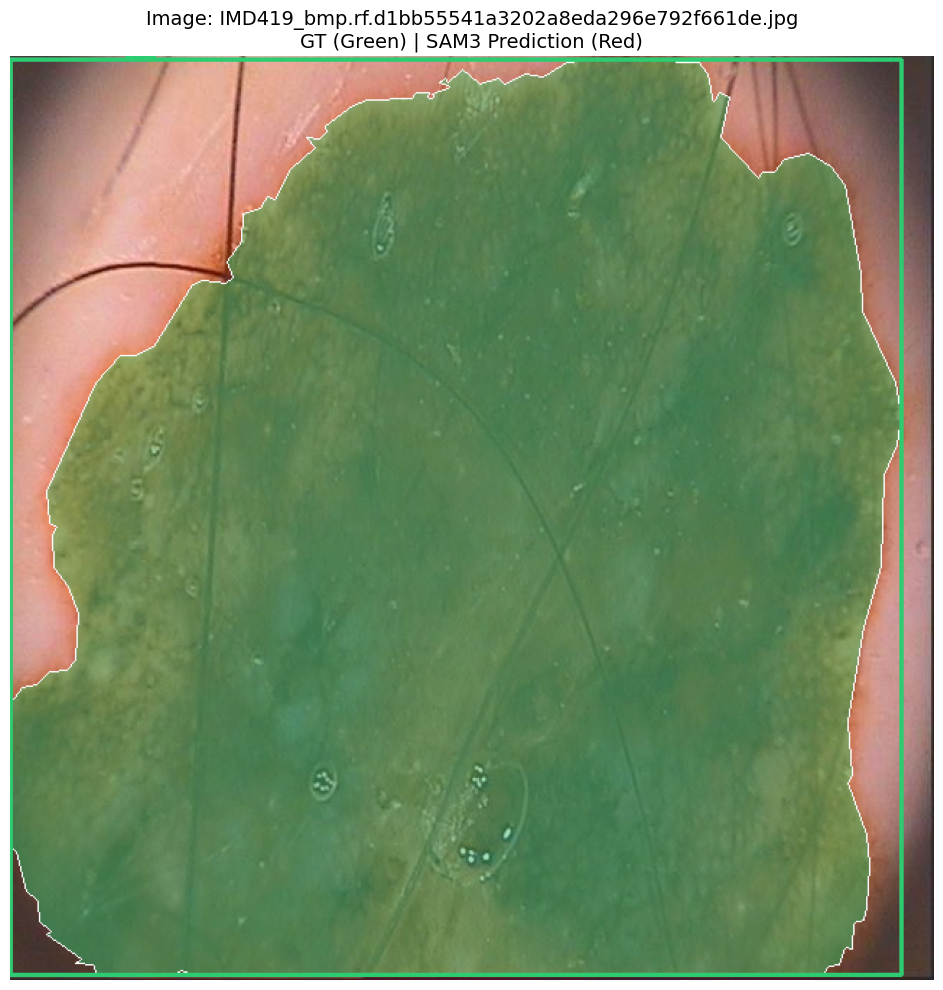

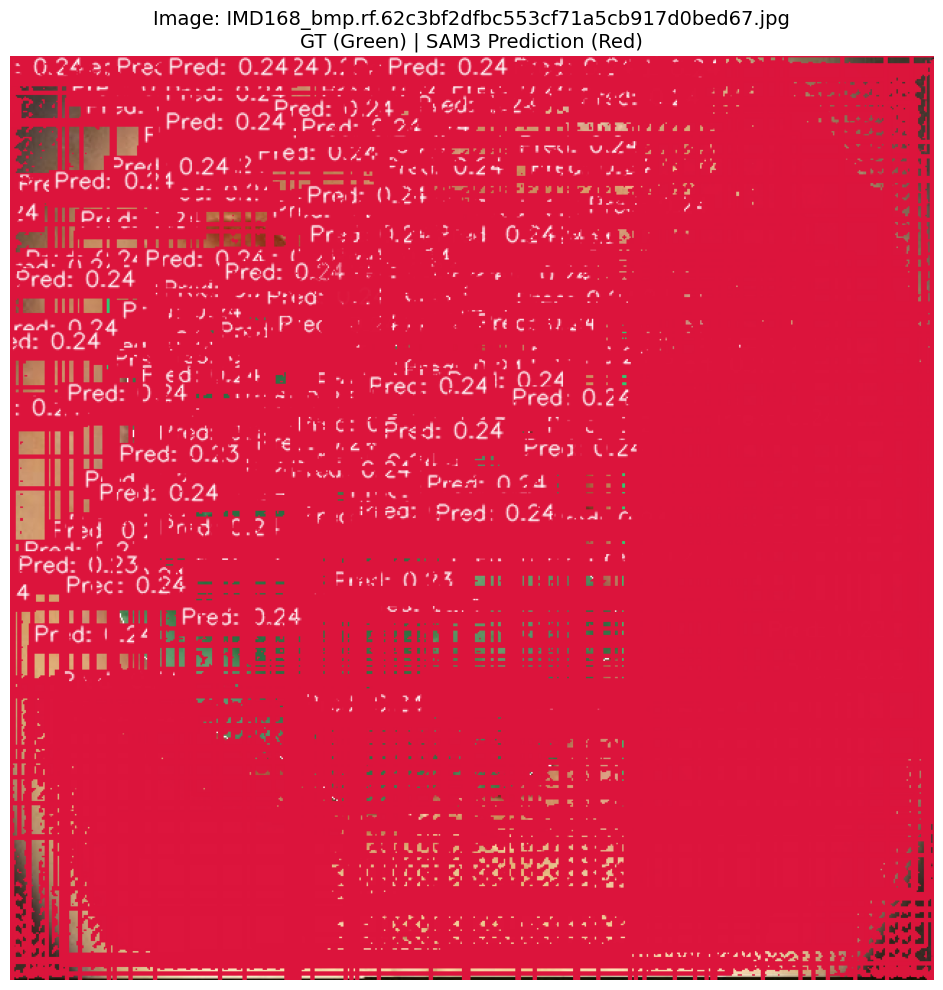

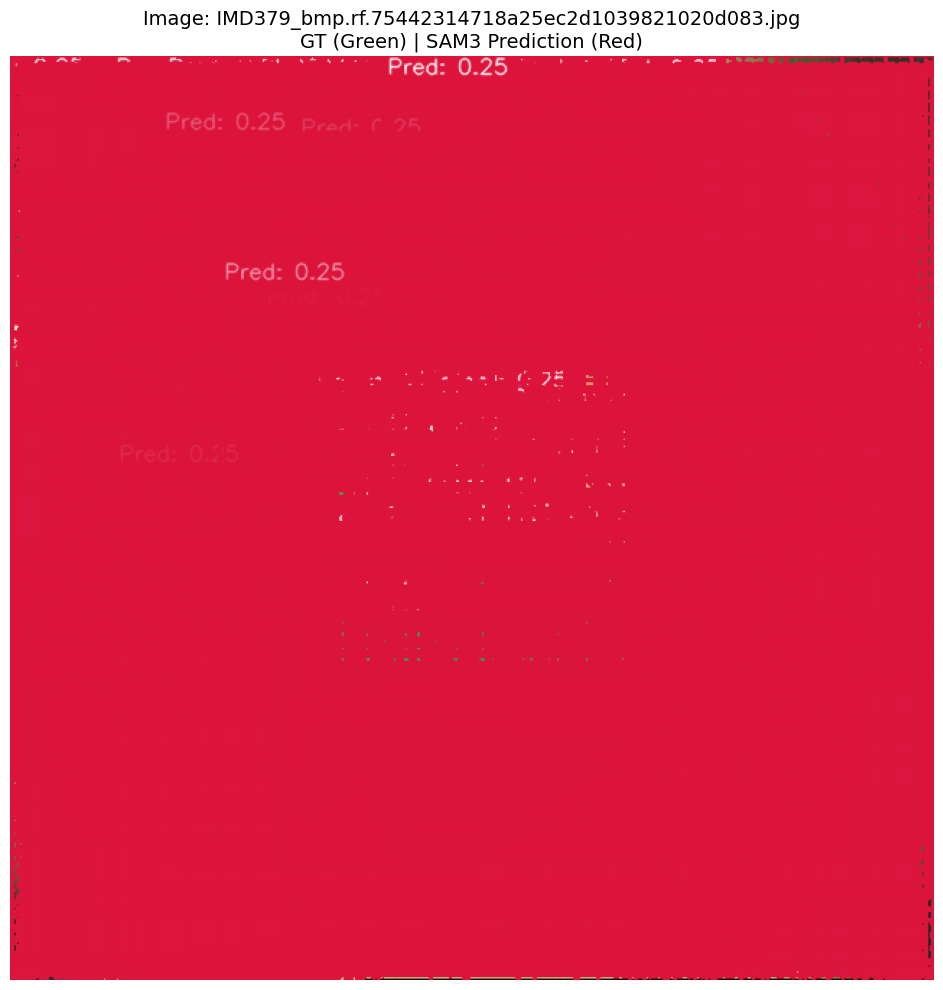

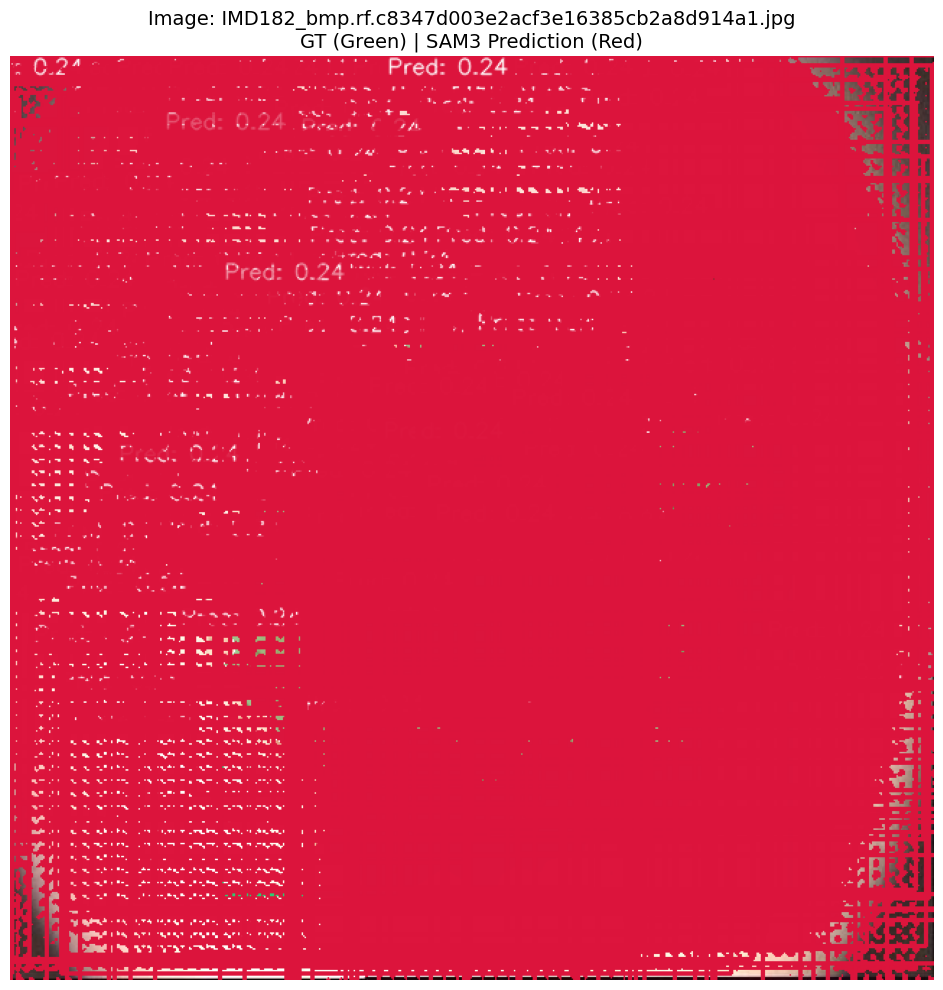

In [ ]:
OVERLAY_MASKS = True 

# 1. Carrega as anotações do Ground Truth de Teste
# Passamos um Path("dummy") para pred_path pois geraremos as preds dinamicamente
_, test_gt_map, test_id_to_filename = load_json_data(Path("dummy"), INFERENCE_CONFIG["test_gt_json"])

# Cria um dicionário reverso (filename -> id) para achar o GT rápido
filename_to_id = {v: k for k, v in test_id_to_filename.items()}

test_files = list(INFERENCE_CONFIG["test_images_dir"].glob("*.jpg")) # Ajuste a extensão se necessário
shown = 0

if not test_files:
    print(f"No images found in test directory: {INFERENCE_CONFIG['test_images_dir']}")
else:
    print(f"Running inference and comparing with GT for {INFERENCE_CONFIG['num_images_to_show']} images...\n")
    
    for img_path in test_files:
        if shown >= INFERENCE_CONFIG["num_images_to_show"]:
            break
            
        original_bgr = cv2.imread(str(img_path))
        if original_bgr is None: continue
            
        # Pega as anotações do dermatologista
        img_id = filename_to_id.get(img_path.name)
        gt_annotations = test_gt_map.get(img_id, []) if img_id else []

        # Roda a inferência do SAM3
        image_pil = Image.open(img_path)
        state = processor.set_image(image_pil)
        results = processor.set_text_prompt(state=state, prompt=INFERENCE_CONFIG["prompt"])

        if OVERLAY_MASKS:
            combined_img = original_bgr.copy()
            
            # 1. Ground Truth (Verde) usando sua função
            _, combined_img = draw_visualizations(combined_img, gt_annotations, is_gt=True, color_override=[113, 204, 46])
            
            # 2. SAM3 Preds (Vermelho) usando a função nativa do SAM3
            combined_img = draw_sam3_predictions(combined_img, results, INFERENCE_CONFIG["prompt"], alpha=INFERENCE_CONFIG["mask_alpha"], color_override=[60, 20, 220])
            
            if len(gt_annotations) > 0 or len(results.get("scores", [])) > 0:
                combined_img_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
                
                plt.figure(figsize=(10, 10))
                plt.imshow(combined_img_rgb)
                plt.title(f"Image: {img_path.name}\nGT (Green) | SAM3 Prediction (Red)", fontsize=14)
                plt.axis('off')
                plt.tight_layout()
                plt.show()
                shown += 1
                
        else:
            img_gt = original_bgr.copy()
            img_pred = original_bgr.copy()
            
            _, img_gt = draw_visualizations(img_gt, gt_annotations, is_gt=True, color_override=[113, 204, 46])
            img_pred = draw_sam3_predictions(img_pred, results, INFERENCE_CONFIG["prompt"], alpha=INFERENCE_CONFIG["mask_alpha"], color_override=[60, 20, 220])
            
            if len(gt_annotations) > 0 or len(results.get("scores", [])) > 0:
                img_gt_rgb = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)
                img_pred_rgb = cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB)
                
                fig, axes = plt.subplots(1, 2, figsize=(16, 8))
                
                axes[0].imshow(img_pred_rgb)
                axes[0].set_title(f"SAM3 Predictions", fontsize=14)
                axes[0].axis('off')
                
                axes[1].imshow(img_gt_rgb)
                axes[1].set_title(f"Ground Truth (Dermatologist)", fontsize=14)
                axes[1].axis('off')
                
                fig.suptitle(f"Image: {img_path.name}", fontsize=16)
                plt.tight_layout()
                plt.show()
                shown += 1